# 📊 Pokemon Card Value & Analytics

Notebook ini mengimplementasikan 3 pilar analitika data untuk aplikasi **REGOKEMON**: 
1. **Macro Market Insights** (Tren global, popularitas, usia set)
2. **Valuation & Mispricing Detector** (Prediksi ML regresi harga wajar)
3. **Trading Signals** (Simulasi simulasi keputusan Buy/Hold/Sell)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

# Konfigurasi visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 💾 Persiapan Data
Load dataset utama `pokemon_cards_dataset_cleaned.csv`.

In [2]:
# Load dataset
df = pd.read_csv('../dataset/pokemon_cards_dataset_cleaned.csv')

# Konversi release_date ke datetime dan buat fitur 'age' (umur dalam tahun)
df['set.release_date'] = pd.to_datetime(df['set.release_date'])
current_year = 2024
df['age'] = current_year - df['release_year']

# Buang data yang tidak punya harga target
df_price = df.dropna(subset=['effective_market_price']).copy()

print(f"Total kartu dengan harga: {len(df_price)}")
df_price.head(3)

Total kartu dengan harga: 19186


,card_id,name,supertype,subtypes,types,hp,number,rarity,artist,set.id,...,release_year,images.small,images.large,prices.tcgplayer_variants.normal.market,prices.tcgplayer_variants.holofoil.market,prices.tcgplayer_variants.reverseHolofoil.market,prices.cardmarket_trend,prices.cardmarket_avg_sell,effective_market_price,age
0,hgss4-1,Aggron,Pokémon,Stage 2,Metal,140.0,1,Rare Holo,Kagemaru Himeno,hgss4,...,2010,https://images.pokemontcg.io/hgss4/1.png,https://images.pokemontcg.io/hgss4/1_hires.png,NaN,9.80,19.41,3.64,2.67,9.80,14
1,xy5-1,Weedle,Pokémon,Basic,Grass,50.0,1,Common,Midori Harada,xy5,...,2015,https://images.pokemontcg.io/xy5/1.png,https://images.pokemontcg.io/xy5/1_hires.png,0.2,NaN,0.61,0.12,0.15,0.20,9
2,pl1-1,Ampharos,Pokémon,Stage 2,Lightning,130.0,1,Rare Holo,Atsuko Nishida,pl1,...,2009,https://images.pokemontcg.io/pl1/1.png,https://images.pokemontcg.io/pl1/1_hires.png,NaN,32.44,24.32,5.78,4.96,32.44,15


---
## 📈 Pilar 1: Macro Market Insights
### 1A. Character Popularity Value Index
Siapa maskot Pokemon termahal rata-rata?

C:\Users\Tigro\AppData\Local\Temp\ipykernel_25540\1670632501.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=char_popularity.values, y=char_popularity.index, palette='viridis')


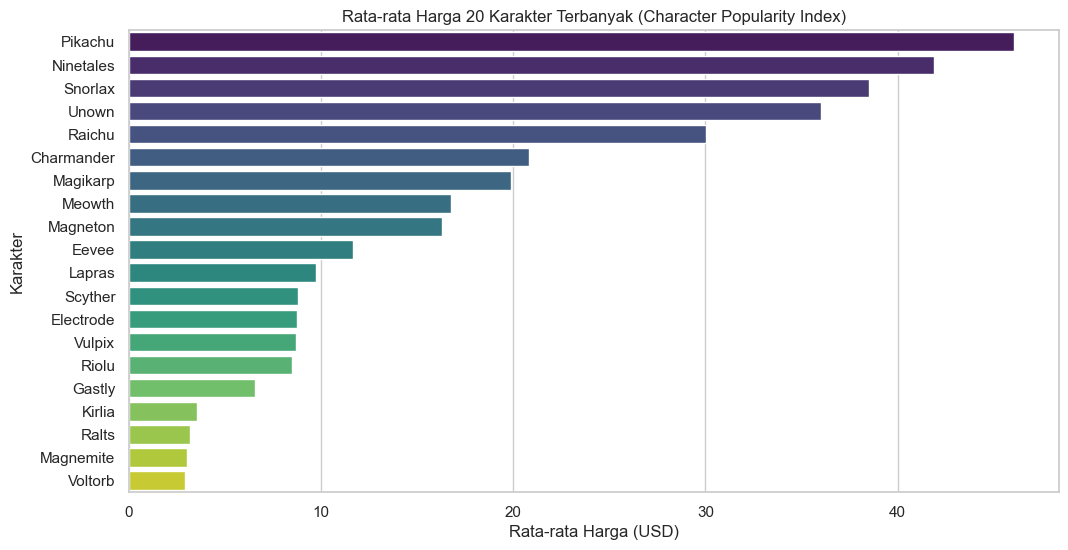

In [3]:
# Ambil 20 Pokemon terpopuler berdasarkan frekuensi kemunculan kartu
top_20_freq = df_price['name'].value_counts().head(20).index

# Hitung rata-rata harga untuk top 20 pokemon ini
char_popularity = df_price[df_price['name'].isin(top_20_freq)].groupby('name')['effective_market_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=char_popularity.values, y=char_popularity.index, palette='viridis')
plt.title('Rata-rata Harga 20 Karakter Terbanyak (Character Popularity Index)')
plt.xlabel('Rata-rata Harga (USD)')
plt.ylabel('Karakter')
plt.show()

### 1B. Vintage Premium Curve
Hubungan antara Umur Set (Age) dengan Rata-rata Harga Pasar (USD).

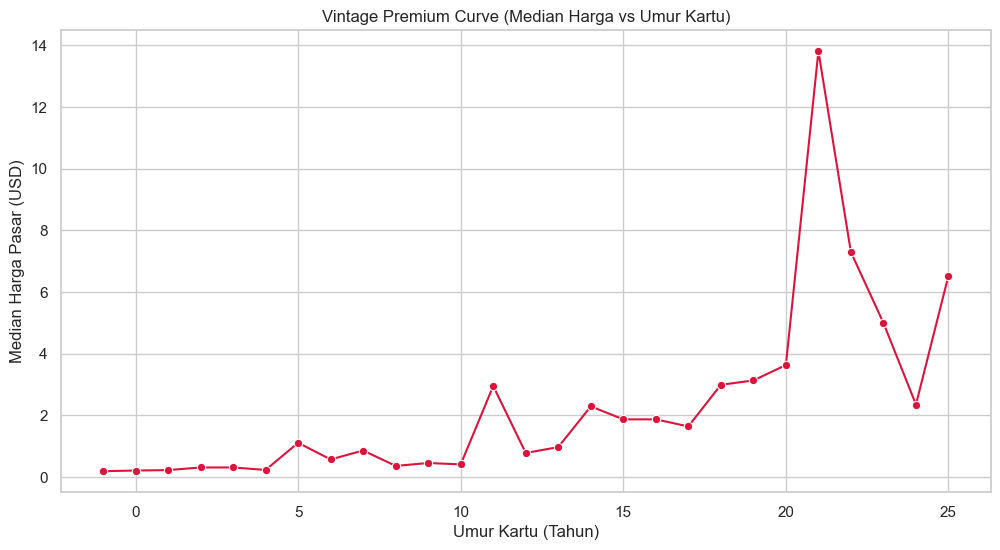

In [4]:
vintage_curve = df_price.groupby('age')['effective_market_price'].median().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=vintage_curve, x='age', y='effective_market_price', marker='o', color='crimson')
plt.title('Vintage Premium Curve (Median Harga vs Umur Kartu)')
plt.xlabel('Umur Kartu (Tahun)')
plt.ylabel('Median Harga Pasar (USD)')
plt.show()

---
## 🤖 Pilar 2: Mispricing Detector (ML Model)
Kita latih model *Random Forest* untuk menebak harga berdasarkan atribut (Supertype, Rarity, Umur, dan HP).

In [5]:
# Persiapan Fitur & Target
features = ['supertype', 'rarity', 'age', 'hp']
target = 'effective_market_price'

df_ml = df_price[features + [target, 'card_id', 'name', 'set.name']].copy()

# Isi HP kosong dengan median (khusus Trainer/Energy)
df_ml['hp'] = df_ml['hp'].fillna(0)

# Encoding Categorical (Rarity, Supertype)
le_rarity = LabelEncoder()
le_supertype = LabelEncoder()

# Handle NaN in rarity and supertype by casting to string
df_ml['rarity'] = df_ml['rarity'].astype(str)
df_ml['supertype'] = df_ml['supertype'].astype(str)

df_ml['rarity_enc'] = le_rarity.fit_transform(df_ml['rarity'])
df_ml['supertype_enc'] = le_supertype.fit_transform(df_ml['supertype'])

X = df_ml[['supertype_enc', 'rarity_enc', 'age', 'hp']]
y = df_ml[target]

# Train-Test Split
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(X, y, df_ml.index, test_size=0.2, random_state=42)

# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Evaluasi
y_pred = rf_model.predict(X_test)
print(f"MAE (Mean Absolute Error): ${mean_absolute_error(y_test, y_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")

MAE (Mean Absolute Error): $19.21
R2 Score: 0.20


Mari kita cari kartu yang **paling Undervalued** (Actual Price jauh lebih murah dari Prediksi).

In [6]:
# Prediksi seluruh dataset
df_ml['predicted_price'] = rf_model.predict(X)

# Hitung Deviasi Mispricing (Undervalued jika Actual < Predicted)
df_ml['mispricing_gap'] = df_ml['predicted_price'] - df_ml['effective_market_price']

# Tampilkan top 5 kartu paling Undervalued (Potensi BUY)
undervalued = df_ml.sort_values(by='mispricing_gap', ascending=False).head(5)
display(undervalued[['card_id', 'name', 'set.name', 'effective_market_price', 'predicted_price', 'mispricing_gap']])

,card_id,name,set.name,effective_market_price,predicted_price,mispricing_gap
11009,ecard3-147,Crobat,Skyridge,447.50,1911.790108,1464.290108
11037,ecard3-149,Ho-oh,Skyridge,800.00,1911.790108,1111.790108
10593,sm9-167,Incineroar-GX,Team Up,8.26,1101.467875,1093.207875
8041,xy2-109,M Kangaskhan-EX,Flashfire,67.49,1115.210186,1047.720186
11451,sm11-229,Dragonite-GX,Unified Minds,58.66,1101.467875,1042.807875


---
## 📊 Pilar 3: Actionable Trading Signals
Mensimulasikan *Valuation Engine* untuk memberikan keputusan Buy/Hold/Sell pada suatu kartu nyata di marketplace berdasarkan Kondisi (Computer Vision).

In [7]:
def evaluate_trading_signal(card_id, offer_price_usd, condition='Clean'):
    """
    Fungsi simulasi untuk mengevaluasi kelayakan investasi/pembelian.
    """
    # 1. Cari base price di dataset
    card_data = df_ml[df_ml['card_id'] == card_id]
    if card_data.empty:
        return "Kartu tidak ditemukan."
    
    base_price = card_data['effective_market_price'].values[0]
    card_name = card_data['name'].values[0]
    set_name = card_data['set.name'].values[0]
    
    # 2. Faktor Kondisi Fisik (Asumsi dari output YOLOv8 CV)
    condition_multipliers = {
        'Clean': 1.00,
        'Scratched': 0.85,
        'Edge Wear': 0.80,
        'Bent/Crease': 0.65
    }
    f_condition = condition_multipliers.get(condition, 1.0)
    
    # 3. Hitung P_final (Harga Wajar Nyata)
    p_final = base_price * f_condition
    
    # 4. Generator Sinyal Transaksi
    deviation = (offer_price_usd - p_final) / p_final
    
    if deviation < -0.10:
        signal = '🟢 BUY (Undervalued)'
    elif deviation <= 0.10:
        signal = '🟡 HOLD (Fair Price)'
    else:
        signal = '🔴 SELL (Overpriced)'
        
    print(f"--- Trading Report: {card_name} ({set_name}) ---")
    print(f"Fisik Terdeteksi : {condition} (Multiplier: {f_condition}x)")
    print(f"Base Price Asli  : ${base_price:.2f}")
    print(f"Fair Price (P_final): ${p_final:.2f}")
    print(f"Harga Penawaran  : ${offer_price_usd:.2f}")
    print(f"Deviasi          : {deviation*100:.1f}%")
    print(f"Sinyal Keputusan : {signal}")

# Simulasi: Temukan Base Set Charizard dengan kondisi lecet, dan penjual menawar $150
evaluate_trading_signal(card_id='base1-4', offer_price_usd=150, condition='Scratched')

--- Trading Report: Charizard (Base) ---
Fisik Terdeteksi : Scratched (Multiplier: 0.85x)
Base Price Asli  : $897.19
Fair Price (P_final): $762.61
Harga Penawaran  : $150.00
Deviasi          : -80.3%
Sinyal Keputusan : 🟢 BUY (Undervalued)
